<a href="https://colab.research.google.com/github/chadiboudaher/mnist-pytorch/blob/main/mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import torch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import libraries for visualizing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


## 1. Getting the dataset

MNIST is a part of PyTorch torchvision datasets.

In [5]:
# Setup training data
train_data = datasets.MNIST(root="data",
                            train=True,
                            download=True,
                            transform=ToTensor(),
                            target_transform=None)

# Setup testing data
test_data = datasets.MNIST(root="root",
                           train=False,
                           download=True,
                           transform=ToTensor(),
                           target_transform=None)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.70MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 52.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [6]:
len(train_data), len(test_data)

(60000, 10000)

## 2. Dataset Classes

Dataset classes represent the available/possible predicted output based on an input image.

In [7]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 3. Check image shape

by checking the image shape we can see:
1. Number of color channels. 1 or 3 (RGB).
2. height.
3. Width.

These information help us recognize wether the size used is suitable (if data is not already processed) for learning.

In [9]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label shape: {label}")

Image shape: torch.Size([1, 28, 28])
Label shape: 5


### 3.1 Visualize our data

we can use matplotlib to see the visualize the dataset

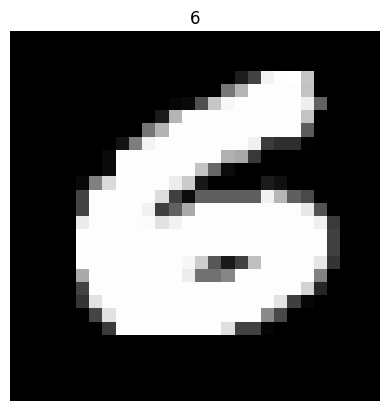

In [29]:
# Set seed
torch.manual_seed(42)

# Get Random image
random_image_number = torch.randint(low=0, high=len(train_data), size=[1]).item()
image, label = train_data[random_image_number]
# print(random_image_number)

# Plot random image
# plt.figure(figsize=(10, 10))
plt.title(label)
plt.imshow(image.squeeze(), cmap="grey")
plt.axis("off")
plt.show();

### 3.2 PLot Multiple Images

The purpose of this is just to check the data.

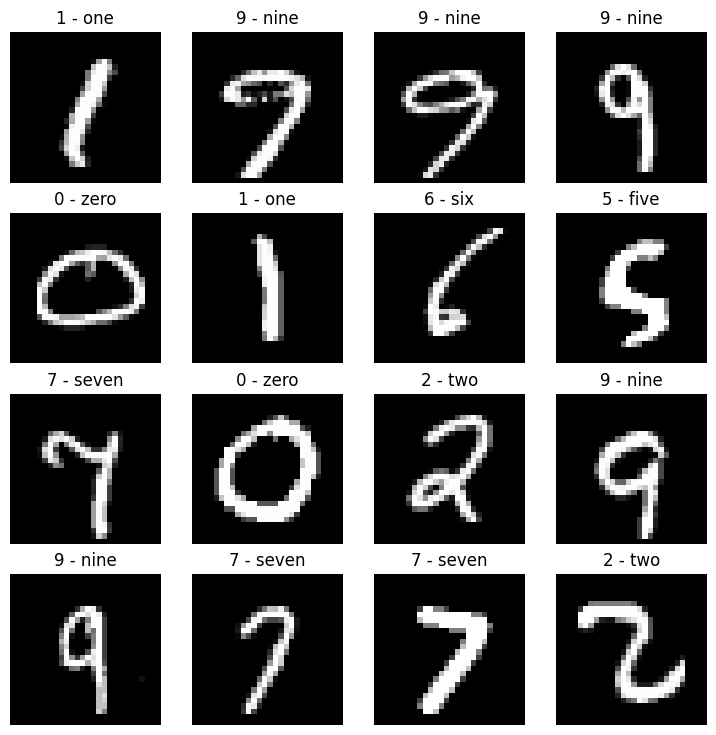

In [34]:
# Plot multiple images
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
  random_index = torch.randint(low=0, high=len(train_data), size=[1]).item()
  image, label = train_data[random_index]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap="grey")
  plt.title(class_names[label])
  plt.axis("off")

## 4. Prepare Dataloader

We want to turn our data into batches.

The advantages of this step:
1. More computationally efficient, our memory may not be able to look at 60,000 images in one hit.
2. It gives our neural network more chances to update its gradient per epochs.

In [36]:
from torch.utils.data import DataLoader

# Setup batch size
BATCH_SIZE = 32

# Turn Dataset into batches
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

# train_dataloader, test_dataloader
print(f"length of the train dataloader is : {len(train_dataloader)} batches of {BATCH_SIZE}..")
print(f"length of the test dataloader is : {len(test_dataloader)} batches of {BATCH_SIZE}..")

length of the train dataloader is : 1875 batches of 32..
length of the test dataloader is : 313 batches of 32..


### 4.1 Explore train and test dataloaders

In [42]:
train_features_batch, train_label_batch = next(iter(train_dataloader))
print(f"train dataloader feature's shape: {train_features_batch.shape}")
print(f"train dataloader label's shape: {train_label_batch.shape}")

train dataloader feature's shape: torch.Size([32, 1, 28, 28])
train dataloader label's shape: torch.Size([32])


## 5. Build a Baseline model

In [43]:
class MNISTv1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [44]:
torch.manual_seed(42)

# Setup model
model_0 = MNISTv1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
).to("cpu")

model_0

MNISTv1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)